In [1720]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('train.csv')

In [1721]:

# Column	Details	Datatype
# PassengerId 	승객 ID (PK)	int64
# Survived (Y)	사망 (0) 생존 (1)	int64
# Pclass 	티켓 등급 (1,2,3)	int64 (범주형)
# Name 	이름	object
# Sex 	성별	object (범주형)
# Age 	나이	float64 
# SibSp 	형제와 배우자 수	int64 
# Parch 	부모와 자식 수	int64 
# Ticket 	티켓 번호	object
# Fare 	요금	float64  
# Cabin 	객실 이름	object (범주형)
# Embarked	승선 항구 (C,Q,S)	object (범주형)

In [ ]:
train_df.head(5) 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1723]:
train_df.info() # 결측치 확인
# Age, Cabin, Embarked 데이터에 NaN이 존재

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [1724]:
train_df.describe(include='all')
#  Fare 데이터에 과도하게 높은 값 존재

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [1725]:
train_df_2 = train_df.copy() # 작업할 복사본 생성

In [1726]:
#  family 변수 생성
# SibSp 와 Parch 모두 가족관계를 나타내는 변수/ 합쳐서 가족의 수를 나타내는 family 변수 생성
def get_family(df):
    df['Family'] = df['SibSp'] + df['Parch'] + 1 #가구
    return df
get_family(train_df_2).head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1


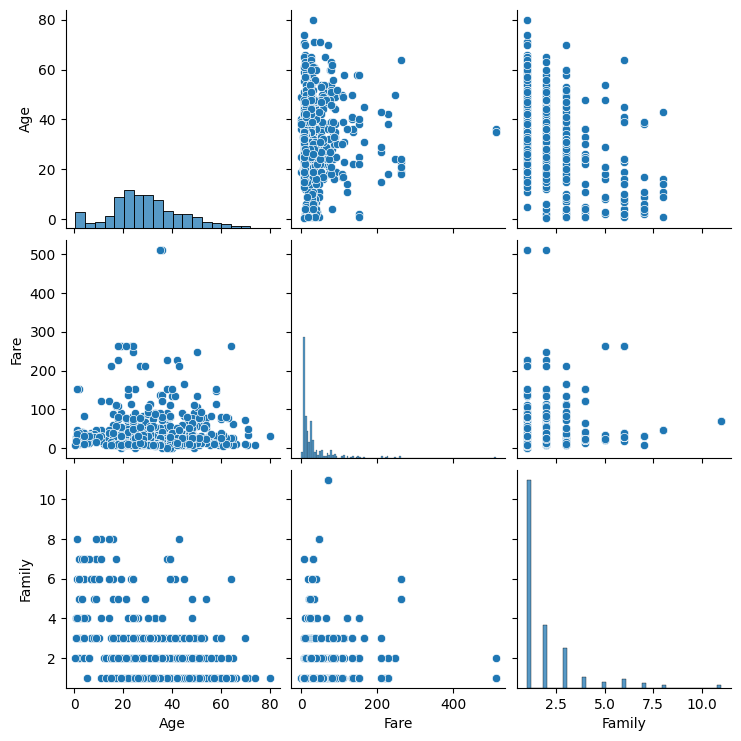

In [1727]:
sns.pairplot(train_df_2[['Age','Fare','Family']])

In [1728]:
train_df_2 = train_df_2[train_df_2['Fare'] < 400]
train_df_2.shape 

(888, 13)

In [1729]:
train_df_2[["Fare"]].describe()

,Fare
count,888.000000
mean,30.582164
std,41.176366
min,0.000000
25%,7.895800
50%,14.454200
75%,30.771850
max,263.000000


In [1730]:
# 결측치 처리
# Age는 Sex와 Pclass 그룹별 평균값으로 대체
# Embarked는 결측치를 Unknown으로 처리

def get_non_missing(df):
    # Age 결측치를 Sex, Pclass 그룹별 평균으로 채우기
    df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
        lambda x: x.fillna(x.mean())
    )

    # 그래도 남아 있는 Age 결측치가 있으면 전체 평균으로 한 번 더 처리
    df['Age'] = df['Age'].fillna(df['Age'].mean())

    # Embarked 결측치는 특정 항구로 억지로 채우지 않고 Unknown으로 처리
    df['Embarked'] = df['Embarked'].fillna('Unknown')

    return df

train_df_2 = get_non_missing(train_df_2)

train_df_2.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          686
Embarked         0
Family           0
dtype: int64

In [1731]:
# 불필요한 컬럼 제거 함수

def get_drop_column(df):
    df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    return df

train_df_2 = get_drop_column(train_df_2)

train_df_2.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,0,3,male,22.0,1,0,7.2500,S,2
1,1,1,female,38.0,1,0,71.2833,C,2
2,1,3,female,26.0,0,0,7.9250,S,1
3,1,1,female,35.0,1,0,53.1000,S,2
4,0,3,male,35.0,0,0,8.0500,S,1


In [1732]:
train_df_2.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Family      0
dtype: int64

In [1733]:
# 1. 결측치 처리
train_df_2 = get_non_missing(train_df_2)

# 2. Age 정수형 변환
train_df_2['Age'] = train_df_2['Age'].astype(int)

# 3. Age 구간화
train_df_2.loc[train_df_2['Age'] <= 16, 'Age'] = 0
train_df_2.loc[(train_df_2['Age'] > 16) & (train_df_2['Age'] <= 32), 'Age'] = 1
train_df_2.loc[(train_df_2['Age'] > 32) & (train_df_2['Age'] <= 48), 'Age'] = 2
train_df_2.loc[(train_df_2['Age'] > 48) & (train_df_2['Age'] <= 64), 'Age'] = 3
train_df_2.loc[train_df_2['Age'] > 64, 'Age'] = 4

# 4. Fare 구간화
train_df_2.loc[train_df_2['Fare'] <= 7.91, 'Fare'] = 0
train_df_2.loc[(train_df_2['Fare'] > 7.91) & (train_df_2['Fare'] <= 14.454), 'Fare'] = 1
train_df_2.loc[(train_df_2['Fare'] > 14.454) & (train_df_2['Fare'] <= 31), 'Fare'] = 2
train_df_2.loc[train_df_2['Fare'] > 31, 'Fare'] = 3
train_df_2['Fare'] = train_df_2['Fare'].astype(int)

In [1734]:
train_df_2.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,0,3,male,1,1,0,0,S,2
1,1,1,female,2,1,0,3,C,2
2,1,3,female,1,0,0,1,S,1
3,1,1,female,2,1,0,3,S,2
4,0,3,male,2,0,0,1,S,1


In [1735]:
# Embarked 결측치 대체 함수
# Pclass와 Fare가 비슷한 승객들의 Embarked를 참고해서 대체

def fill_embarked_by_pclass_fare(df):
    # Embarked 결측치를 Unknown으로 표시한 경우도 처리
    missing_idx = df[(df['Embarked'].isnull()) | (df['Embarked'] == 'Unknown')].index

    for idx in missing_idx:
        pclass_value = df.loc[idx, 'Pclass']
        fare_value = df.loc[idx, 'Fare']

        # 같은 Pclass를 가진 승객 중 Embarked가 결측치가 아닌 데이터만 선택
        similar = df[
            (df['Pclass'] == pclass_value) &
            (df['Embarked'].notnull()) &
            (df['Embarked'] != 'Unknown')
        ].copy()

        # Fare 차이 계산
        similar['fare_diff'] = abs(similar['Fare'] - fare_value)

        # Fare가 가장 비슷한 승객 10명 선택
        nearest = similar.sort_values('fare_diff').head(10)

        # 그 승객들 중 가장 많이 나온 Embarked로 대체
        fill_value = nearest['Embarked'].mode()[0]

        df.loc[idx, 'Embarked'] = fill_value

    return df

train_df_2 = fill_embarked_by_pclass_fare(train_df_2)

train_df_2['Embarked'].value_counts()

Embarked
S    645
C    166
Q     77
Name: count, dtype: int64

In [1736]:
train_df_2 = pd.get_dummies(
    train_df_2,
    columns=['Sex', 'Embarked'],
    dtype='int'
)

train_df_2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Family,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,1,0,0,2,0,1,0,0,1
1,1,1,2,1,0,3,2,1,0,1,0,0
2,1,3,1,0,0,1,1,1,0,0,0,1
3,1,1,2,1,0,3,2,1,0,0,0,1
4,0,3,2,0,0,1,1,0,1,0,0,1


In [1737]:
# Pclass가 높을수록(Pclass가 1에 가까워질수록) 생존율이 높음.
# 남자보다 여자의 생존율이 높음.(Sex=female일 때 생존 가능성이 74%로 매우 높음.)
# 동행이 적은 경우 생존율이 높음.
# Age<=4일 때 생존확률이 높음.
# 15-25세가 가장 많이 사망함.
# 대부분의 탑승객은 15-35세인 것으로 확인됨.
# Pclass=3인 탑승객이 가장 많았지만 사망한 사람의 수도 가장 많음.
# Pclass=2인 승객 중 유아는 대부분 생존함.
# Pclass=1인 탑승객의 생존확률이 상대적으로 높음.
# 여성일 경우 생존확률이 더 높은 것을 확인할 수 있음. 다만, Embarked=C일 때, 남성의 생존확률이 더욱 더 높음.
# 승선지가 S 또는 C인 경우 생존한 승객들의 평균 요금이 비교적 높음.

In [1738]:
# 1. Age*Class 변수 생성
train_df_2['Age*Class'] = train_df_2['Age'] * train_df_2['Pclass']


train_df_2.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Family,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Age*Class
0,0,3,1,1,0,0,2,0,1,0,0,1,3
1,1,1,2,1,0,3,2,1,0,1,0,0,2
2,1,3,1,0,0,1,1,1,0,0,0,1,3
3,1,1,2,1,0,3,2,1,0,0,0,1,2
4,0,3,2,0,0,1,1,0,1,0,0,1,6


In [1739]:
train_df_2['Fare'].value_counts()

Fare
2    229
0    223
3    219
1    217
Name: count, dtype: int64

In [1740]:
train_df_2.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Family',
       'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Age*Class'],
      dtype='str')

In [1741]:
train_df_2.info()

<class 'pandas.DataFrame'>
Index: 888 entries, 0 to 890
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Survived    888 non-null    int64
 1   Pclass      888 non-null    int64
 2   Age         888 non-null    int32
 3   SibSp       888 non-null    int64
 4   Parch       888 non-null    int64
 5   Fare        888 non-null    int32
 6   Family      888 non-null    int64
 7   Sex_female  888 non-null    int32
 8   Sex_male    888 non-null    int32
 9   Embarked_C  888 non-null    int32
 10  Embarked_Q  888 non-null    int32
 11  Embarked_S  888 non-null    int32
 12  Age*Class   888 non-null    int64
dtypes: int32(7), int64(6)
memory usage: 105.1 KB


In [1742]:
X = train_df_2.drop('Survived', axis=1)
y = train_df_2['Survived']

In [1743]:
print(X.shape)
print(y.shape)

(888, 12)
(888,)


In [1744]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (710, 12)
X_test : (178, 12)
y_train: (710,)
y_test : (178,)


In [1745]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# scaler = StandardScaler() # accuracy= 0.7835820895522388
scaler = MinMaxScaler() # accuracy= 0.8314606547355652

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1746]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_200 (Dense)           (None, 64)                832       
                                                                 
 dropout_97 (Dropout)        (None, 64)                0         
                                                                 
 dense_201 (Dense)           (None, 16)                1040      
                                                                 
 dropout_98 (Dropout)        (None, 16)                0         
                                                                 
 dense_202 (Dense)           (None, 8)                 136       
                                                                 
 dropout_99 (Dropout)        (None, 8)                 0         
                                                                 
 dense_203 (Dense)           (None, 1)               

In [1747]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [1748]:
hist = model.fit(
    X_train_scaled,
    y_train,
    epochs=64,
    batch_size=32,
)

Epoch 1/64
23/23 [==============================] - 1s 1ms/step - loss: 0.6930 - accuracy: 0.5338
Epoch 2/64
23/23 [==============================] - 0s 1ms/step - loss: 0.6531 - accuracy: 0.6465
Epoch 3/64
23/23 [==============================] - 0s 1ms/step - loss: 0.6166 - accuracy: 0.6958
Epoch 4/64
23/23 [==============================] - 0s 1ms/step - loss: 0.5771 - accuracy: 0.7282
Epoch 5/64
23/23 [==============================] - 0s 1ms/step - loss: 0.5388 - accuracy: 0.7563
Epoch 6/64
23/23 [==============================] - 0s 1ms/step - loss: 0.5300 - accuracy: 0.7465
Epoch 7/64
23/23 [==============================] - 0s 1ms/step - loss: 0.5229 - accuracy: 0.7732
Epoch 8/64
23/23 [==============================] - 0s 2ms/step - loss: 0.5077 - accuracy: 0.7732
Epoch 9/64
23/23 [==============================] - 0s 1ms/step - loss: 0.4792 - accuracy: 0.7972
Epoch 10/64
23/23 [==============================] - 0s 1ms/step - loss: 0.5028 - accuracy: 0.7761
Epoch 11/64
23/23 [

In [1749]:
score = model.evaluate(X_test_scaled, y_test, verbose=1)

print('\nloss=', score[0])
print('accuracy=', score[1])


6/6 [==============================] - 0s 2ms/step - loss: 0.4321 - accuracy: 0.8202

loss= 0.43207645416259766
accuracy= 0.8202247023582458


-----------------------------------------

## 여러 테스트

In [1750]:
# # 독립변수 / 종속변수 분리
# X = train_df_2.drop('Survived', axis=1)
# y = train_df_2['Survived']

# # 제거할 변수
# drop_cols = ['Sex_male', 'Age*Class', 'Embarked_S']

# # 변수 제거한 데이터 생성
# X_selected = X.drop(columns=drop_cols)

# print(X_selected.columns)

In [1751]:
# import random
# import numpy as np
# import tensorflow as tf

# # 랜덤 고정
# random.seed(42)
# np.random.seed(42)
# tf.random.set_seed(42)

# # 데이터 분리
# X_train, X_test, y_train, y_test = train_test_split(
#     X_selected,
#     y,
#     test_size=0.1,
#     random_state=42,
#     stratify=y
# )

# # 스케일링
# scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 모델 생성
# model = Sequential()

# model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))
# model.add(Dropout(0.2))

# model.add(Dense(16, activation='relu'))
# model.add(Dropout(0.2))

# model.add(Dense(8, activation='relu'))

# model.add(Dense(1, activation='sigmoid'))

# # 모델 컴파일
# model.compile(
#     loss='binary_crossentropy',
#     optimizer='adam',
#     metrics=['accuracy']
# )

# # 모델 학습
# hist = model.fit(
#     X_train_scaled,
#     y_train,
#     epochs=100,
#     batch_size=32,
#     validation_split=0.2,
#     verbose=1
# )

# # 평가
# score = model.evaluate(X_test_scaled, y_test, verbose=1)

# print('\nloss=', score[0])
# print('accuracy=', score[1])
# print('accuracy(%)=', score[1] * 100)

In [1752]:
# import numpy as np
# import pandas as pd

# # 기준 정확도 확인
# baseline_loss, baseline_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# print("기준 정확도:", baseline_acc)
# print("기준 정확도(%):", baseline_acc * 100)

In [1753]:
# # 변수 중요도 계산

# feature_names = X.columns
# results = []

# # 랜덤 고정
# rng = np.random.default_rng(42)

# for i, feature in enumerate(feature_names):
    
#     acc_list = []
    
#     # 한 번만 섞으면 결과가 우연일 수 있으므로 5번 반복
#     for _ in range(5):
#         X_test_permuted = X_test_scaled.copy()
        
#         # i번째 변수 값만 랜덤하게 섞기
#         rng.shuffle(X_test_permuted[:, i])
        
#         # 섞은 데이터로 평가
#         loss, acc = model.evaluate(X_test_permuted, y_test, verbose=0)
#         acc_list.append(acc)
    
#     # 평균 정확도 계산
#     permuted_acc = np.mean(acc_list)
    
#     # 정확도 감소량 계산
#     importance = baseline_acc - permuted_acc
    
#     results.append({
#         "Feature": feature,
#         "Baseline_Accuracy": baseline_acc,
#         "Permuted_Accuracy": permuted_acc,
#         "Importance": importance
#     })

# importance_df = pd.DataFrame(results)

# # 중요도 높은 순서로 정렬
# importance_df = importance_df.sort_values(by="Importance", ascending=False)

# importance_df

In [1754]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))

# plt.barh(
#     importance_df["Feature"],
#     importance_df["Importance"]
# )

# plt.xlabel("Importance")
# plt.ylabel("Feature")
# plt.title("DNN Feature Importance by Permutation Importance")
# plt.gca().invert_yaxis()
# plt.show()